# Experiment comparison

Editable local evidence, learning curves, milestone uncertainty, cross-regime comparisons and costs in one notebook. Run All refreshes retained data only. No cell trains, evaluates games or accesses a tracker. Edit any loading or plotting cell; report refresh never overwrites this notebook.

In [1]:
from pathlib import Path
# Relative to this notebook's directory.
DATA_ROOT = Path('.').resolve()

## Load evidence

In [2]:
from collections import defaultdict
import json
from pathlib import Path
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
from manabot.arena.models import canonical_sha256, file_sha256
from manabot.training.models import TrainingRun
from manabot.training.monitor_evaluation import MonitorResult
from manabot.training.monitoring import training_dashboard

# Editable discovery: narrow these lists to selected executions if needed.
run_paths = sorted(DATA_ROOT.rglob("run.json"))
monitor_paths = sorted(DATA_ROOT.rglob("monitor.json"))
attempt_paths = sorted(DATA_ROOT.rglob("attempt-*/attempt.json"))
execution_paths = sorted(DATA_ROOT.rglob("experiment.json"))
executions = [(p, json.loads(p.read_text())) for p in execution_paths]
runs = [(p, TrainingRun.model_validate_json(p.read_text())) for p in run_paths]
monitors = [(p, MonitorResult.model_validate_json(p.read_text())) for p in monitor_paths]
attempts = [(p, json.loads(p.read_text())) for p in attempt_paths]
training = [(p, run, training_dashboard(run)) for p, run in runs]
# Preserve additional scalar diagnostics beyond the dashboard's default panels.
for _, run, dashboard in training:
    diagnostics = [item for stage in run.stages for item in stage.diagnostics]
    for row, diagnostic in zip(dashboard.rows, diagnostics, strict=True):
        for key, value in diagnostic.items():
            if isinstance(value, (int, float)) and not isinstance(value, bool) and f"rl/{key}" not in row:
                row[f"diagnostic/{key}"] = value
labels = {run.id: f"{run.regime.id} / seed {run.seed} / {run.id}" for _, run in runs}
# Evidence hashes describe this refresh, not a mutable claim about older output.
evidence = [{"path": str(p), "sha256": file_sha256(p)}
            for p in [*run_paths, *monitor_paths, *attempt_paths, *execution_paths]]
display(Markdown(f"Loaded **{len(runs)} training attempts**, **{len(monitors)} milestone cohorts**, "
                 f"**{len(attempts)} evaluator attempts**. All data are retained local records."))


Loaded **4 training attempts**, **4 milestone cohorts**, **4 evaluator attempts**. All data are retained local records.

## All retained learning metrics

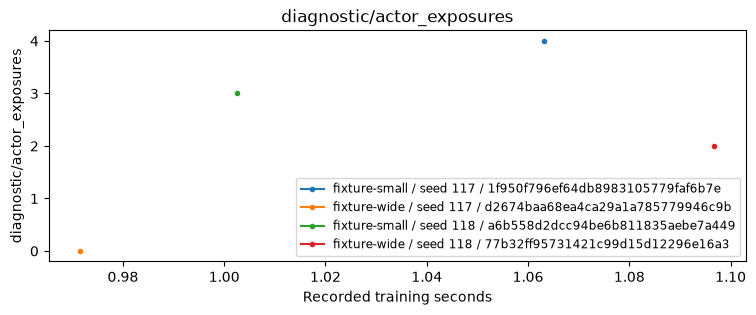

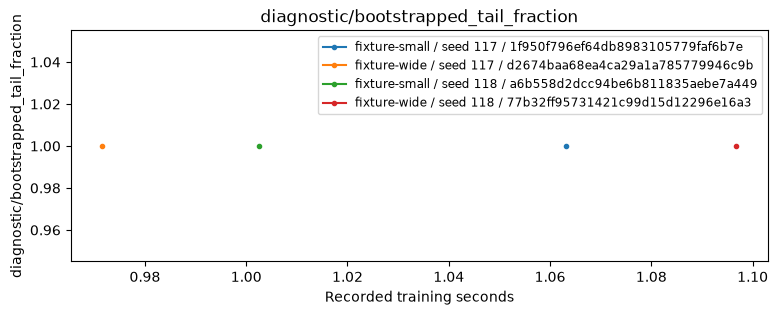

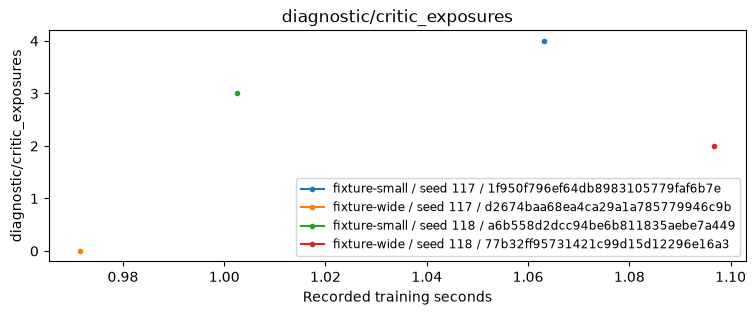

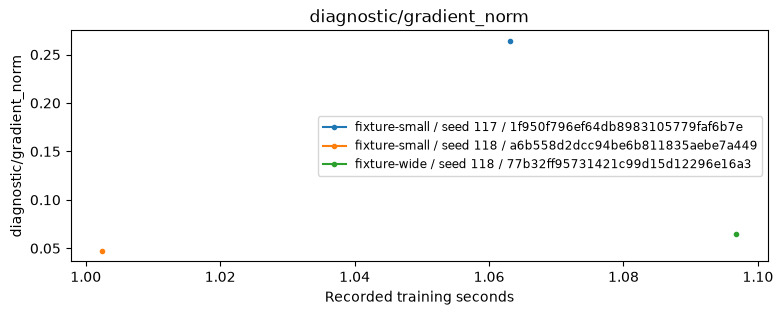

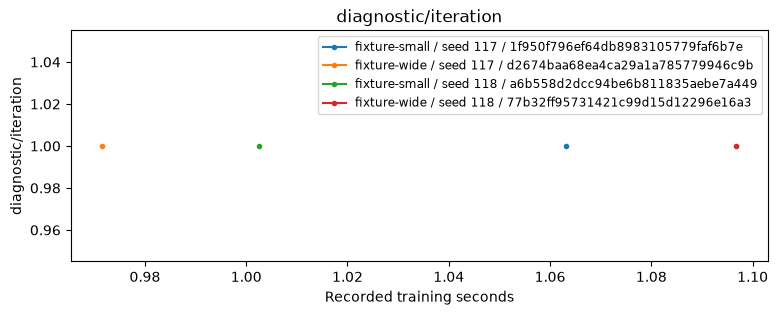

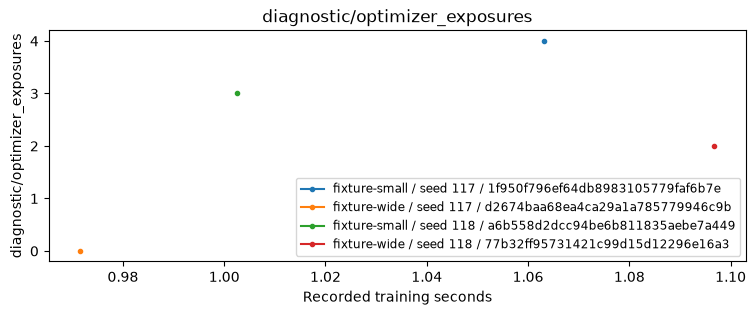

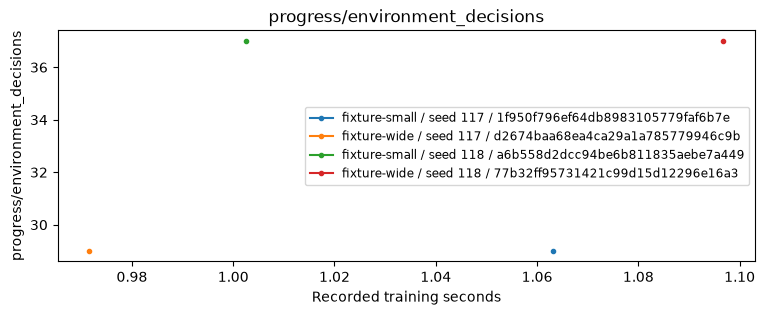

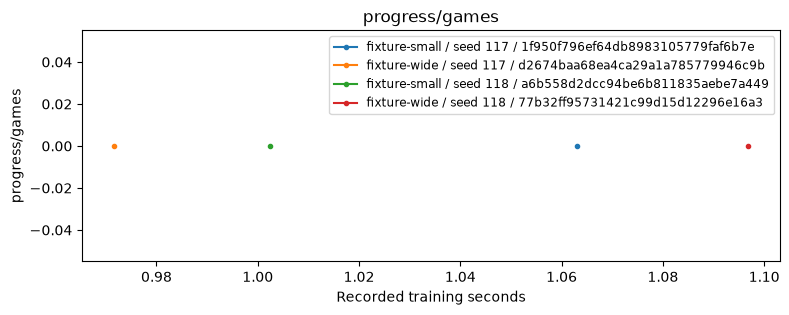

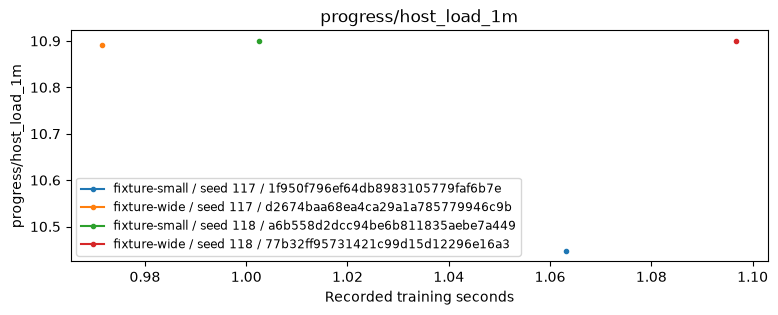

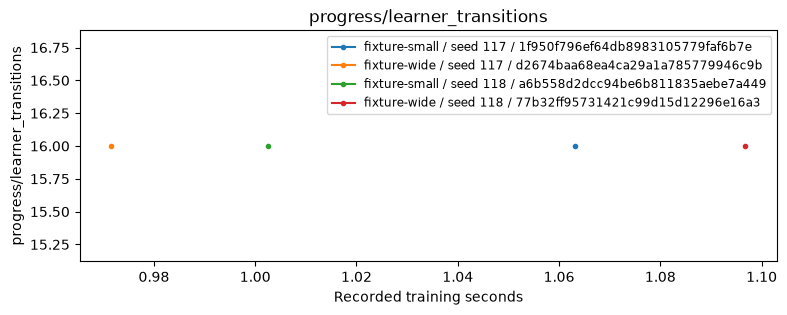

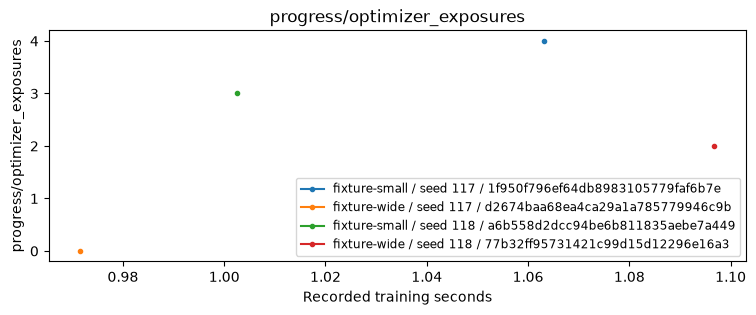

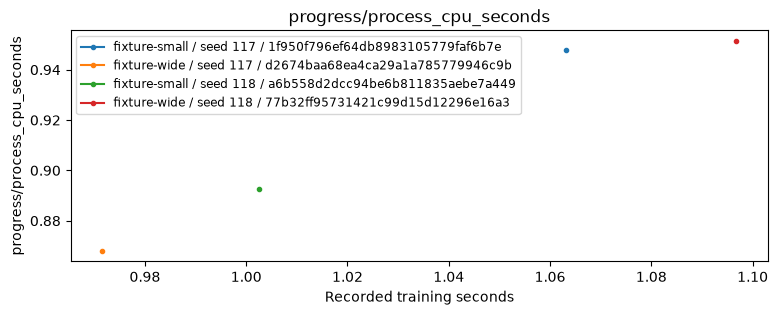

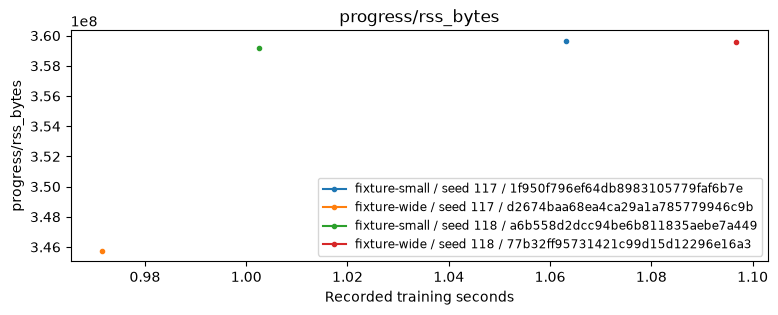

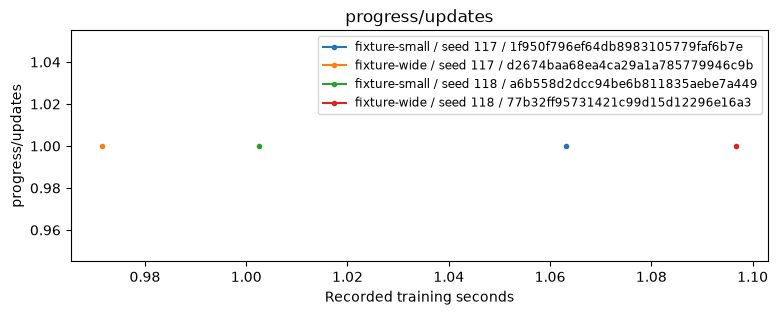

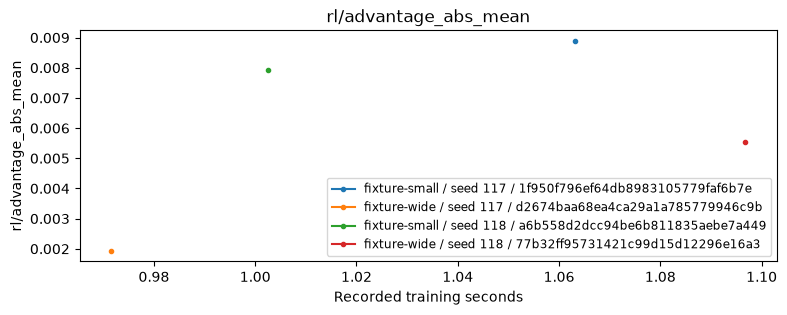

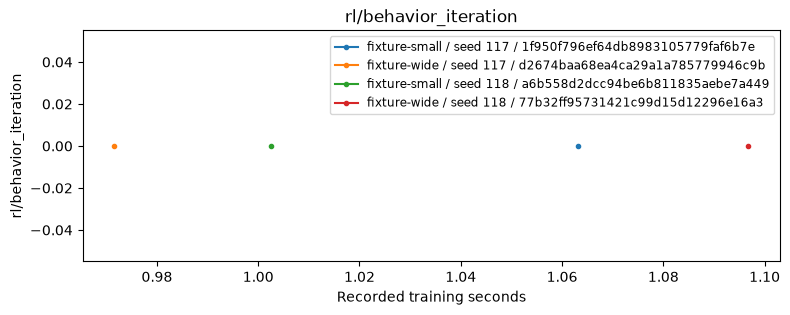

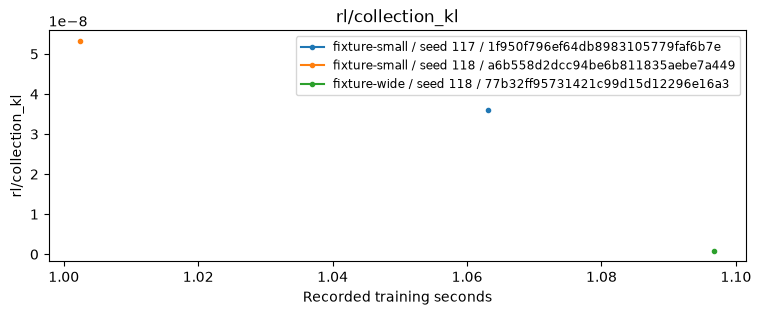

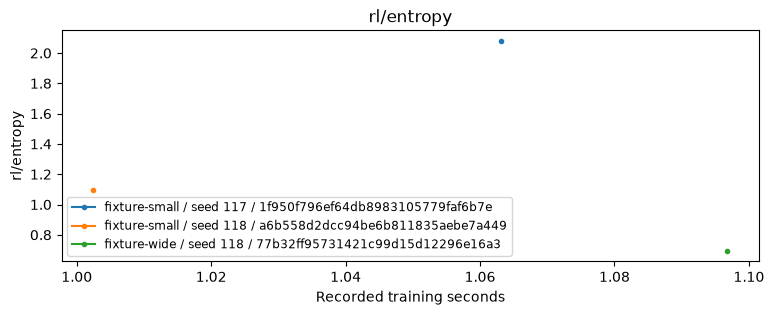

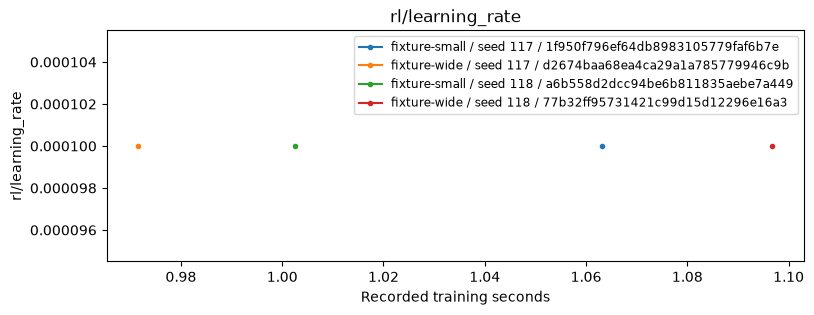

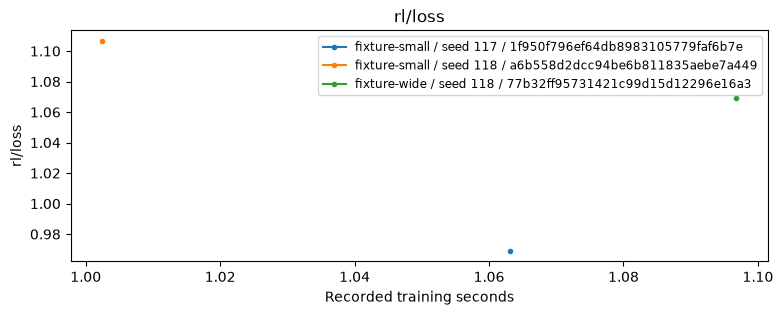

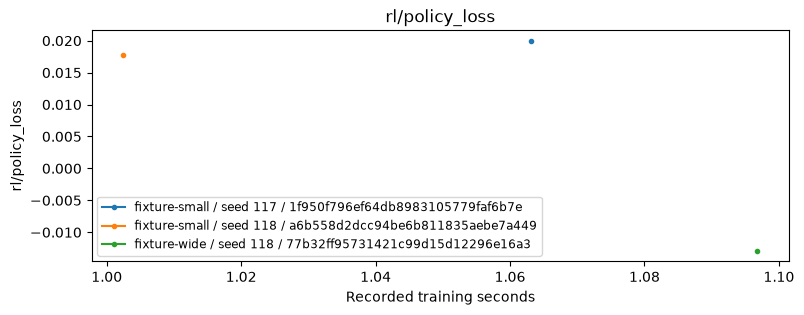

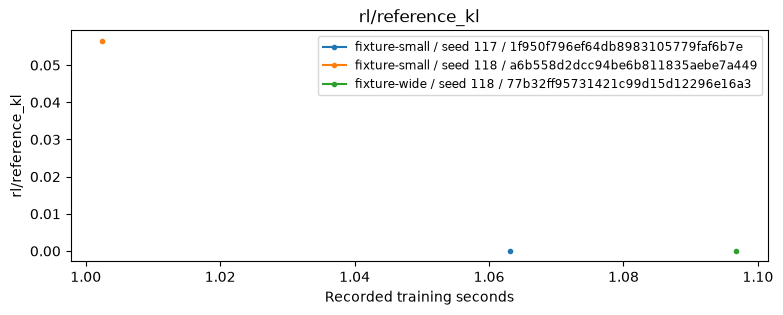

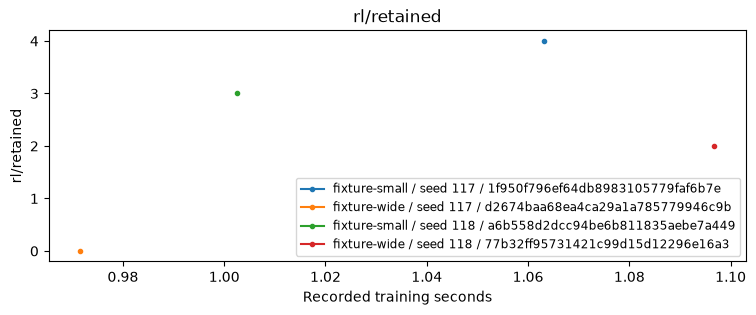

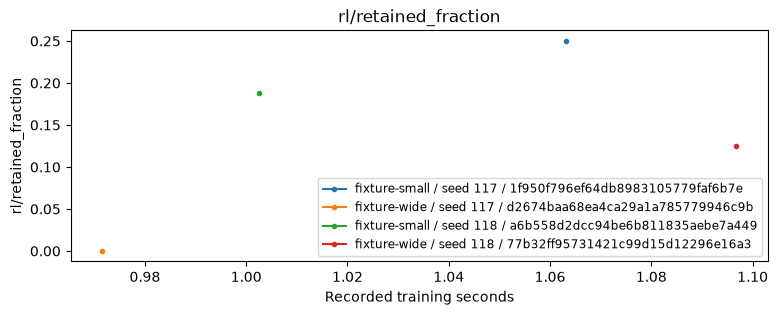

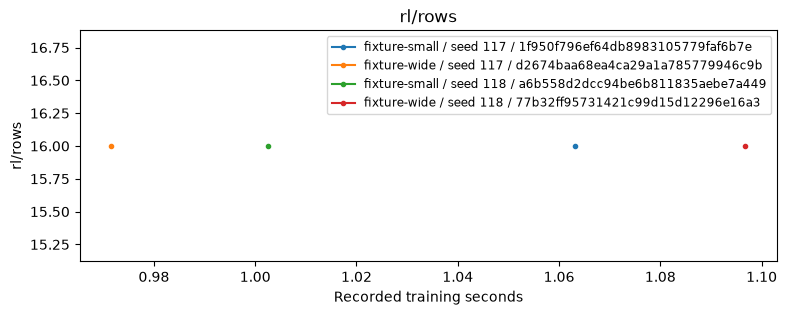

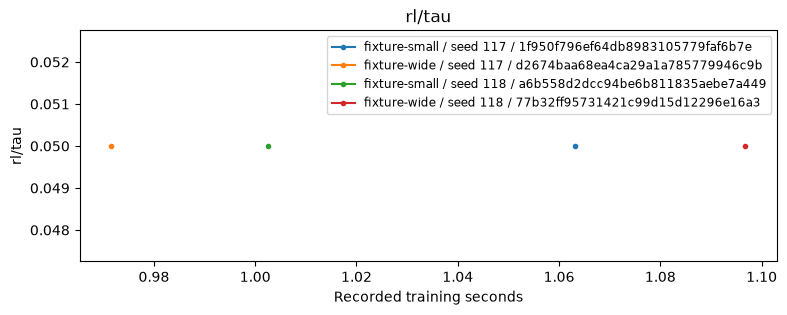

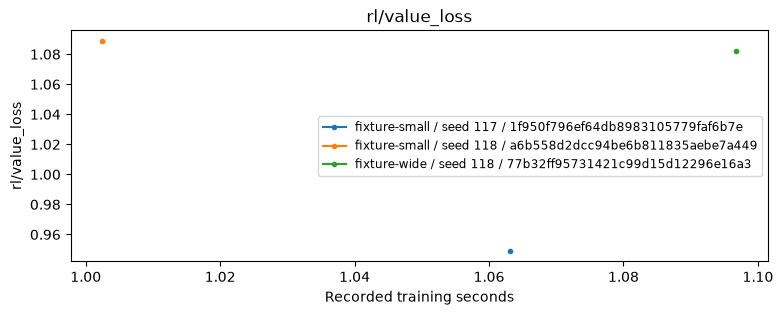

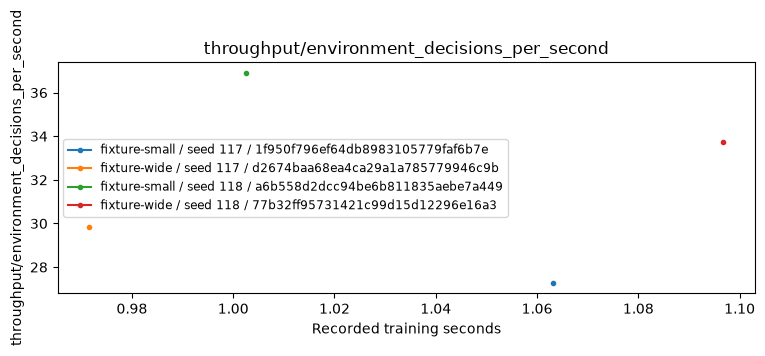

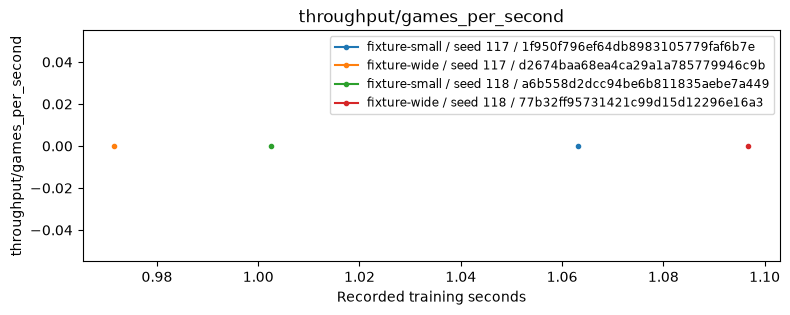

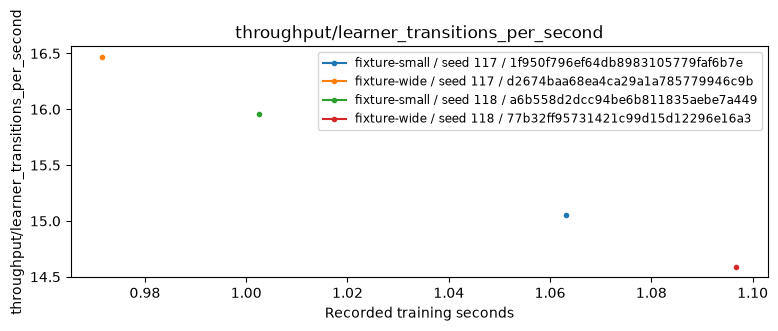

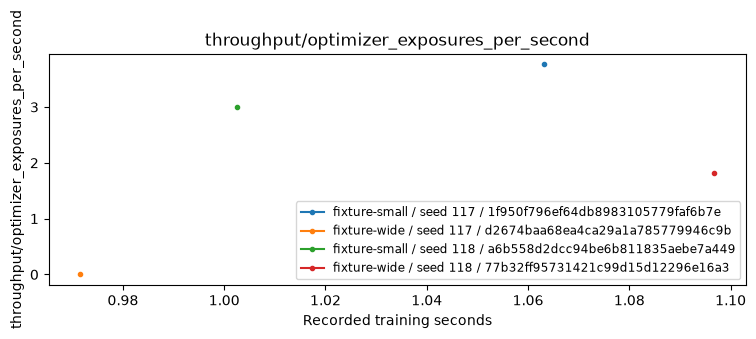

In [3]:
# None plots every available numeric learning/resource metric. Edit to focus.
METRICS = None
available = sorted({key for _, _, dashboard in training for row in dashboard.rows
                    for key, value in row.items()
                    if isinstance(value, (int, float)) and not isinstance(value, bool)
                    and not key.startswith(("availability/", "elapsed/"))
                    and key not in {"progress/observation", "progress/training_seconds", "stage/ordinal"}})
for metric in available if METRICS is None else METRICS:
    fig, ax = plt.subplots(figsize=(9, 3))
    for _, run, dashboard in training:
        points = [(row["progress/training_seconds"], row[metric])
                  for row in dashboard.rows
                  if metric in row and "progress/training_seconds" in row]
        if points:
            x, y = zip(*points)
            ax.plot(x, y, marker=".", label=labels[run.id])
    ax.set(xlabel="Recorded training seconds", ylabel=metric, title=metric)
    if ax.lines:
        ax.legend(fontsize="small")
    else:
        ax.text(.5, .5, "No recorded time coordinates; unavailable", ha="center", transform=ax.transAxes)
    plt.show()
    plt.close(fig)
if not available:
    display(Markdown("Learning curves unavailable: no numeric diagnostics retained."))


## Milestone rates and uncertainty

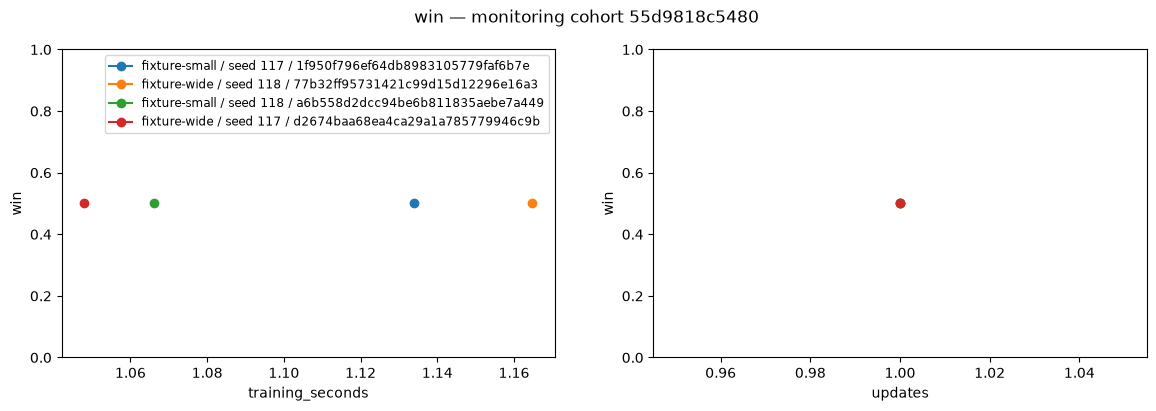

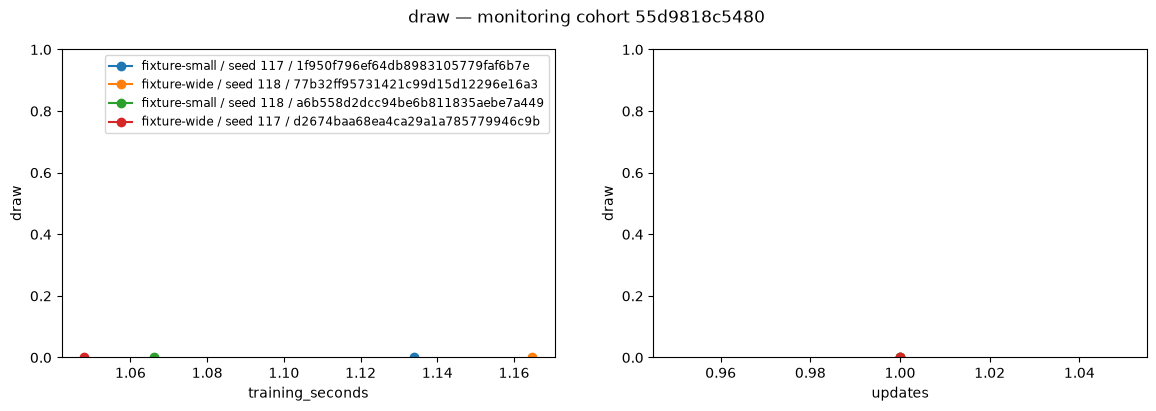

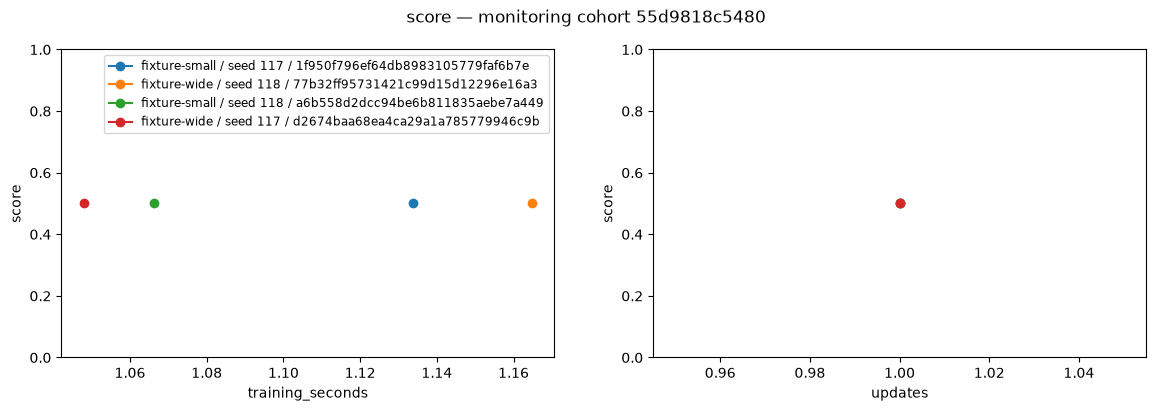

Bands resample complete four-leg deals conditional on each checkpoint. They are not training-seed uncertainty. Cross-regime curves are descriptive; monitoring deals are inspected, not scientific held-out evidence.

In [4]:
# Keep incompatible cohorts/opponents/worlds in separate comparison panels.
# Failed or interrupted queue attempts suppress rates even if a partial result exists.
failed = {p.parent.resolve() for p, a in attempts if a["status"] in {"failed", "interrupted"}}
panels = defaultdict(list)
for path, result in monitors:
    panel = canonical_sha256({"protocol": result.protocol.model_dump(mode="json"),
                              "opponent": result.opponent.model_dump(mode="json"),
                              "arena": result.key.model_dump(mode="json")})
    if result.status == "completed" and not any(parent in failed for parent in path.resolve().parents):
        panels[panel].append(result)
for panel, results in panels.items():
    # Three rates, each against both cost and learner updates, in this notebook.
    for metric in ("win", "draw", "score"):
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        for run_id in sorted({r.run_id for r in results}):
            rows = sorted((r for r in results if r.run_id == run_id), key=lambda r: r.coordinates.training_seconds)
            for ax, coordinate in zip(axes, ("training_seconds", "updates")):
                valid = [r for r in rows if getattr(r, metric) is not None]
                x = [getattr(r.coordinates, coordinate) for r in valid]
                means = [getattr(r, metric).mean for r in valid]
                lo = [getattr(r, metric).lower for r in valid]
                hi = [getattr(r, metric).upper for r in valid]
                ax.plot(x, means, marker="o", label=labels.get(run_id, run_id))
                ax.fill_between(x, lo, hi, alpha=.15)
                ax.set(xlabel=coordinate, ylabel=metric, ylim=(0, 1))
        axes[0].legend(fontsize="small")
        fig.suptitle(f"{metric} — monitoring cohort {panel[:12]}")
        plt.show()
        plt.close(fig)
if not panels:
    display(Markdown("Milestone rates unavailable: no complete compatible monitoring cohort."))
display(Markdown("Bands resample complete four-leg deals conditional on each checkpoint. "
                 "They are not training-seed uncertainty. Cross-regime curves are descriptive; "
                 "monitoring deals are inspected, not scientific held-out evidence."))


## Cross-regime comparison at observed cost

In [5]:
# Editable common-cost comparison: last completed checkpoint at a shared cutoff.
# No extrapolation, interpolation, rank-based selection or protocol change.
comparison_rows = []
for panel, results in panels.items():
    grouped = {run_id: sorted((r for r in results if r.run_id == run_id),
                              key=lambda r: r.coordinates.training_seconds)
               for run_id in sorted({r.run_id for r in results})}
    lower = max(rows[0].coordinates.training_seconds for rows in grouped.values())
    upper = min(rows[-1].coordinates.training_seconds for rows in grouped.values())
    if lower > upper:
        display(Markdown(f"Cohort {panel[:12]}: no shared observed cost range."))
        continue
    cutoff = upper  # Edit within [lower, upper]; preserve original checkpoint coordinates.
    for run_id, rows in grouped.items():
        selected = max((r for r in rows if r.coordinates.training_seconds <= cutoff),
                       key=lambda r: r.coordinates.training_seconds)
        comparison_rows.append({"cohort": panel, "run": labels.get(run_id, run_id),
                                "cutoff_seconds": cutoff,
                                "checkpoint_seconds": selected.coordinates.training_seconds,
                                "checkpoint_sha256": selected.artifact["sha256"],
                                "score": selected.score.model_dump() if selected.score else None})
display(comparison_rows)


Cohort 55d9818c5480: no shared observed cost range.

[]

## Costs, monitoring and failures

{'training_attempt_seconds': 4.419665709021501,
 'evaluator_process_seconds': 47.169547416997375,
 'standalone_arena_seconds': 0,
 'recorded_additive_seconds': 51.589213126018876,
 'running_attempts': 0}

[{'evidence': '/Users/jack/src/etude.evaluate-campaign-checkpoints-during-training/.runs/etu113-validation/gate/test_tiny_comparison_evaluates0/comparison/experiment.json',
  'status': 'completed',
  'wall_seconds': 50.75134366599377,
  'process_seconds': 61.304800542013254,
  'evaluator_seconds': 47.169547416997375,
  'host_dollars': None,
  'error': None}]

[{'allowance_seconds': 20.0,
  'case': 'fixture-small',
  'error': None,
  'finished_unix': 1791311038.967498,
  'ordinal': 0,
  'path': '/Users/jack/src/etude.evaluate-campaign-checkpoints-during-training/.runs/etu113-validation/gate/test_tiny_comparison_evaluates0/comparison/training/attempt-0000',
  'process_seconds': 3.485413166024955,
  'recovery_parent': None,
  'run_id': '1f950f796ef64db8983105779faf6b7e',
  'seed': 117,
  'started_unix': 1791311035.478774,
  'status': 'completed',
  'execution_evidence': '/Users/jack/src/etude.evaluate-campaign-checkpoints-during-training/.runs/etu113-validation/gate/test_tiny_comparison_evaluates0/comparison/experiment.json'},
 {'allowance_seconds': 20.0,
  'case': 'fixture-wide',
  'error': None,
  'finished_unix': 1791311042.668787,
  'ordinal': 1,
  'path': '/Users/jack/src/etude.evaluate-campaign-checkpoints-during-training/.runs/etu113-validation/gate/test_tiny_comparison_evaluates0/comparison/training/attempt-0001',
  'process_seconds': 

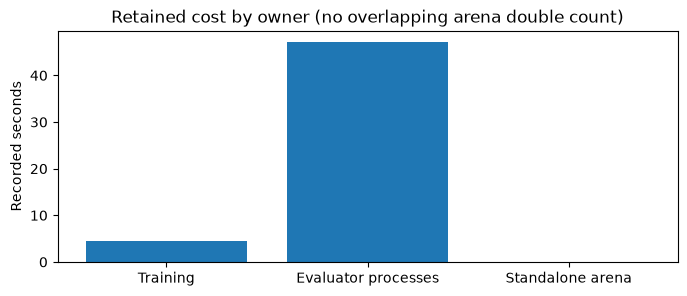

[{'run': 'fixture-small / seed 117 / 1f950f796ef64db8983105779faf6b7e',
  'status': 'completed',
  'seconds': 1.135547542013228,
  'prior_seconds_reference_only': 0.0,
  'monitor_export_seconds_included': 0.0,
  'error': None,
  'evidence': '/Users/jack/src/etude.evaluate-campaign-checkpoints-during-training/.runs/etu113-validation/gate/test_tiny_comparison_evaluates0/comparison/training/attempt-0000/run.json'},
 {'run': 'fixture-wide / seed 117 / d2674baa68ea4ca29a1a785779946c9b',
  'status': 'completed',
  'seconds': 1.049952375004068,
  'prior_seconds_reference_only': 0.0,
  'monitor_export_seconds_included': 0.0,
  'error': None,
  'evidence': '/Users/jack/src/etude.evaluate-campaign-checkpoints-during-training/.runs/etu113-validation/gate/test_tiny_comparison_evaluates0/comparison/training/attempt-0001/run.json'},
 {'run': 'fixture-small / seed 118 / a6b558d2dcc94be6b811835aebe7a449',
  'status': 'completed',
  'seconds': 1.0675735420081764,
  'prior_seconds_reference_only': 0.0,


[{'charged_seconds': 10.928031541989185,
  'error': None,
  'finished_unix': 1791311074.055625,
  'identity': '2dc22cb072ae25b00df0ca98a90a3efcb2ba945a373dba02bce899a3964ded5b',
  'job_sha256': '20150148d31827f865688483a39a046d3ad805876a42a7d7e68f9b431186b115',
  'ordinal': 2,
  'reserved_seconds': 140.0,
  'started_unix': 1791311063.126515,
  'status': 'completed',
  'evidence': '/Users/jack/src/etude.evaluate-campaign-checkpoints-during-training/.runs/etu113-validation/gate/test_tiny_comparison_evaluates0/comparison/monitoring/attempt-2dc22cb072ae25b00df0ca98a90a3efcb2ba945a373dba02bce899a3964ded5b/attempt.json'},
 {'charged_seconds': 10.473192875011591,
  'error': None,
  'finished_unix': 1791311063.121464,
  'identity': '67f9bbf16f6dece811b4f64cb40131698433fb0520beae96844d76c8dcdefdd3',
  'job_sha256': 'a78fb0486890631b168966ee9c3fb833aac366b06ec771b0e48213f927115993',
  'ordinal': 1,
  'reserved_seconds': 140.0,
  'started_unix': 1791311052.6474612,
  'status': 'completed',
  'evi

[{'evidence': '/Users/jack/src/etude.evaluate-campaign-checkpoints-during-training/.runs/etu113-validation/gate/test_tiny_comparison_evaluates0/comparison/monitoring/attempt-2dc22cb072ae25b00df0ca98a90a3efcb2ba945a373dba02bce899a3964ded5b/evaluation/monitor.json',
  'status': 'completed',
  'error': None,
  'completed_games': 4,
  'expected_games': 4,
  'evaluation_seconds': 9.147866207989864,
  'host_load_before': (11.3369140625, 19.2939453125, 23.63525390625),
  'host_load_after': (11.3896484375, 19.1728515625, 23.56689453125),
  'concurrent_activity': 'campaign learner may overlap; one evaluator CPU thread; no contention correction'},
 {'evidence': '/Users/jack/src/etude.evaluate-campaign-checkpoints-during-training/.runs/etu113-validation/gate/test_tiny_comparison_evaluates0/comparison/monitoring/attempt-67f9bbf16f6dece811b4f64cb40131698433fb0520beae96844d76c8dcdefdd3/evaluation/monitor.json',
  'status': 'completed',
  'error': None,
  'completed_games': 4,
  'expected_games': 4,


Additive process seconds are not elapsed wall time or hardware-normalized compute. Active jobs and absent records are incomplete. Imported producer costs, source preparation and unobserved failures require their execution receipts; missing cost is not zero. Host load describes contention and does not correct throughput.

In [6]:
# Cost owners stay distinct. Worker process charges include arena work; do not
# add monitor.evaluation_seconds again for jobs already charged by the queue.
training_costs = [{"run": labels[r.id], "status": r.status, "seconds": r.seconds,
                   "prior_seconds_reference_only": r.prior_seconds,
                   "monitor_export_seconds_included": r.monitoring_export_seconds,
                   "error": r.error, "evidence": str(p)} for p, r in runs]
evaluation_costs = [{**a, "evidence": str(p)} for p, a in attempts]
standalone_monitors = [(p, r) for p, r in monitors
                       if not any((parent / "attempt.json").exists() for parent in p.parents)]
training_seconds = sum(r.seconds for _, r in runs)
evaluator_seconds = sum(a["charged_seconds"] for _, a in attempts)
standalone_seconds = sum(r.evaluation_seconds or 0 for _, r in standalone_monitors)
costs = {"training_attempt_seconds": training_seconds,
         "evaluator_process_seconds": evaluator_seconds,
         "standalone_arena_seconds": standalone_seconds,
         "recorded_additive_seconds": training_seconds + evaluator_seconds + standalone_seconds,
         "running_attempts": sum(a["status"] == "running" for _, a in attempts)}
display(costs)
# Execution receipts include process startup, failed launches, polling overhead
# and conservative crash charges absent from TrainingRun/arena-only subtotals.
execution_costs = [{"evidence": str(p), "status": r["status"],
                    "wall_seconds": r["elapsed_seconds"],
                    "process_seconds": r["process_seconds"],
                    "evaluator_seconds": r["evaluator_seconds"],
                    "host_dollars": r["host_dollars"], "error": r["error"]}
                   for p, r in executions]
display(execution_costs)
# Includes learners that failed before they could export a TrainingRun.
display([{**a, "execution_evidence": str(p)} for p, r in executions for a in r["attempts"]])
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(["Training", "Evaluator processes", "Standalone arena"],
       [training_seconds, evaluator_seconds, standalone_seconds])
ax.set(ylabel="Recorded seconds", title="Retained cost by owner (no overlapping arena double count)")
plt.show()
plt.close(fig)
display(training_costs)
display(evaluation_costs)
monitoring_details = [{"evidence": str(p), "status": r.status, "error": r.error,
                       "completed_games": sum(row.valid for row in r.rows),
                       "expected_games": r.expected_games,
                       "evaluation_seconds": r.evaluation_seconds,
                       "host_load_before": r.host_load_before,
                       "host_load_after": r.host_load_after,
                       "concurrent_activity": r.concurrent_activity} for p, r in monitors]
display(monitoring_details)
display(Markdown("Additive process seconds are not elapsed wall time or hardware-normalized compute. "
                 "Active jobs and absent records are incomplete. Imported producer costs, source preparation "
                 "and unobserved failures require their execution receipts; missing cost is not zero. "
                 "Host load describes contention and does not correct throughput."))


## Interpretation (editable)

Observations: record measured changes with paths and hashes below.

Conclusions: distinguish uncertainty, missing evidence and hypotheses.

The experiment skill owns research-ledger updates and selection of the next experiment; this software does not rewrite repository knowledge.

In [7]:
# Evidence links/hashes for citing this exact refresh.
display(evidence)

[{'path': '/Users/jack/src/etude.evaluate-campaign-checkpoints-during-training/.runs/etu113-validation/gate/test_tiny_comparison_evaluates0/comparison/training/attempt-0000/run.json',
  'sha256': 'a1b339587db7a18921c267f2e8d36229fb98f69420cb5fefb6df5c918824de96'},
 {'path': '/Users/jack/src/etude.evaluate-campaign-checkpoints-during-training/.runs/etu113-validation/gate/test_tiny_comparison_evaluates0/comparison/training/attempt-0001/run.json',
  'sha256': 'a1ec2f8a9301f1cd5d0f1735d7b48678dad210f3014828034f4c7ac3979e3034'},
 {'path': '/Users/jack/src/etude.evaluate-campaign-checkpoints-during-training/.runs/etu113-validation/gate/test_tiny_comparison_evaluates0/comparison/training/attempt-0002/run.json',
  'sha256': '4fbe0bd8addd876e93538dff6cab0ad62f334743d272790ef0cc4f6a710ab635'},
 {'path': '/Users/jack/src/etude.evaluate-campaign-checkpoints-during-training/.runs/etu113-validation/gate/test_tiny_comparison_evaluates0/comparison/training/attempt-0003/run.json',
  'sha256': '01628973

In [8]:
personal_note = 'keep this edit'